In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style="darkgrid")

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# Load cleaned hourly dataset
df = pd.read_csv('../data/cleaned_hourly.csv',
                 parse_dates=['datetime'],
                 index_col='datetime')

# Load baseline predictions
predictions = pd.read_csv('../data/baseline_predictions.csv',
                          parse_dates=['datetime'],
                          index_col='datetime')

# Load XGBoost model
xgb_model = joblib.load('../models/xgboost_model.pkl')
features   = joblib.load('../models/feature_list.pkl')

print(f"✅ Data loaded!")
print(f"Dataset shape      : {df.shape}")
print(f"Predictions shape  : {predictions.shape}")
print(f"\nPredictions columns: {list(predictions.columns)}")
print(f"\nFirst few predictions:")
print(predictions.head())

✅ Data loaded!
Dataset shape      : (34589, 7)
Predictions shape  : (6885, 3)

Predictions columns: ['actual', 'rf_predicted', 'xgb_predicted']

First few predictions:
                       actual  rf_predicted  xgb_predicted
datetime                                                  
2010-02-13 01:00:00  0.330500      0.348568       0.356914
2010-02-13 02:00:00  0.286967      0.359728       0.349347
2010-02-13 03:00:00  0.292133      0.361275       0.363087
2010-02-13 04:00:00  0.337200      0.354379       0.369140
2010-02-13 05:00:00  0.357167      0.393591       0.393278


✅ Peak Hour Detection Complete!
Peak threshold     : 1.5750 kW
Total peak hours   : 8,648
Peak hour %        : 25.0%


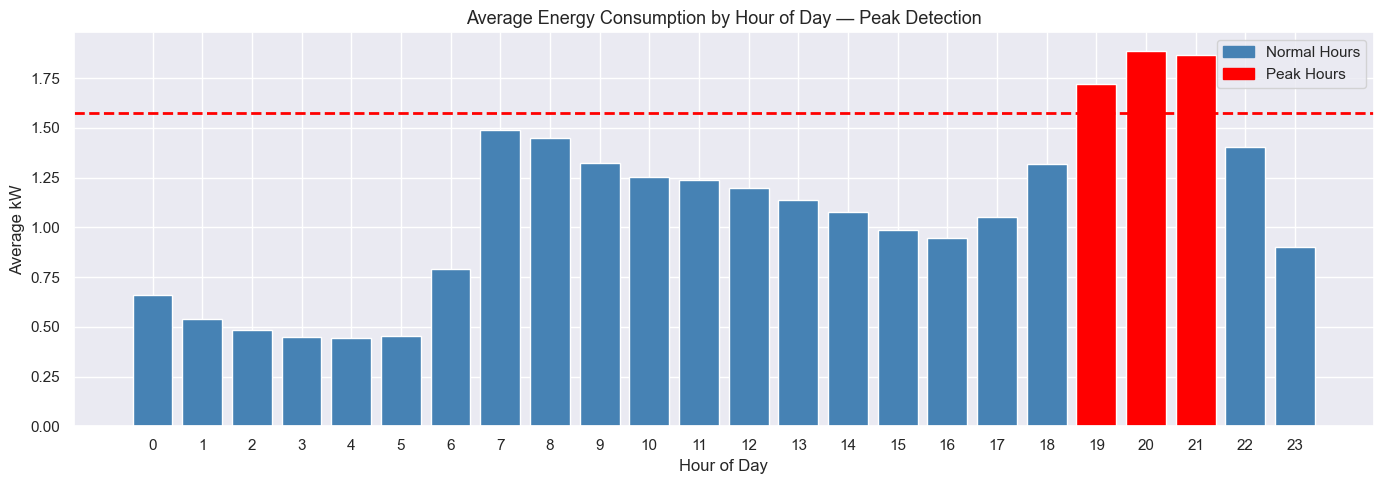


🔴 Peak Hours Detected: [19, 20, 21]


In [3]:
# ⚡ Peak Hour Detection Engine
def detect_peak_hours(df, threshold_percentile=75):
    """Detect peak consumption hours based on percentile threshold"""
    
    df_analysis = df[['Global_active_power']].copy()
    
    # Add time features
    df_analysis['hour']       = df_analysis.index.hour
    df_analysis['day_of_week']= df_analysis.index.dayofweek
    df_analysis['is_weekend'] = (df_analysis.index.dayofweek >= 5).astype(int)
    
    # Calculate threshold
    threshold = np.percentile(df_analysis['Global_active_power'], threshold_percentile)
    
    # Flag peak hours
    df_analysis['is_peak']        = (df_analysis['Global_active_power'] >= threshold).astype(int)
    df_analysis['consumption_level'] = pd.cut(
        df_analysis['Global_active_power'],
        bins=[0, 
              np.percentile(df_analysis['Global_active_power'], 25),
              np.percentile(df_analysis['Global_active_power'], 75),
              df_analysis['Global_active_power'].max()],
        labels=['Low', 'Medium', 'High']
    )
    
    return df_analysis, threshold

df_analysis, peak_threshold = detect_peak_hours(df)

print(f"✅ Peak Hour Detection Complete!")
print(f"Peak threshold     : {peak_threshold:.4f} kW")
print(f"Total peak hours   : {df_analysis['is_peak'].sum():,}")
print(f"Peak hour %        : {df_analysis['is_peak'].mean()*100:.1f}%")

# Average consumption by hour
hourly_avg = df_analysis.groupby('hour')['Global_active_power'].mean()

plt.figure(figsize=(14, 5))
colors = ['red' if v >= peak_threshold else 'steelblue' for v in hourly_avg.values]
plt.bar(hourly_avg.index, hourly_avg.values, color=colors, edgecolor='white')
plt.axhline(y=peak_threshold, color='red', linestyle='--', linewidth=2, label=f'Peak Threshold ({peak_threshold:.2f} kW)')
plt.title('Average Energy Consumption by Hour of Day — Peak Detection', fontsize=13)
plt.xlabel('Hour of Day')
plt.ylabel('Average kW')
plt.xticks(range(24))
plt.legend()

# Add labels
low_patch  = mpatches.Patch(color='steelblue', label='Normal Hours')
high_patch = mpatches.Patch(color='red', label='Peak Hours')
plt.legend(handles=[low_patch, high_patch])
plt.tight_layout()
plt.savefig('../data/peak_hours.png', dpi=150)
plt.show()

# Print peak hours
peak_hours = hourly_avg[hourly_avg >= peak_threshold].index.tolist()
print(f"\n🔴 Peak Hours Detected: {peak_hours}")

✅ Anomaly Detection Complete!
Total anomalies detected : 293
Anomaly percentage       : 0.85%


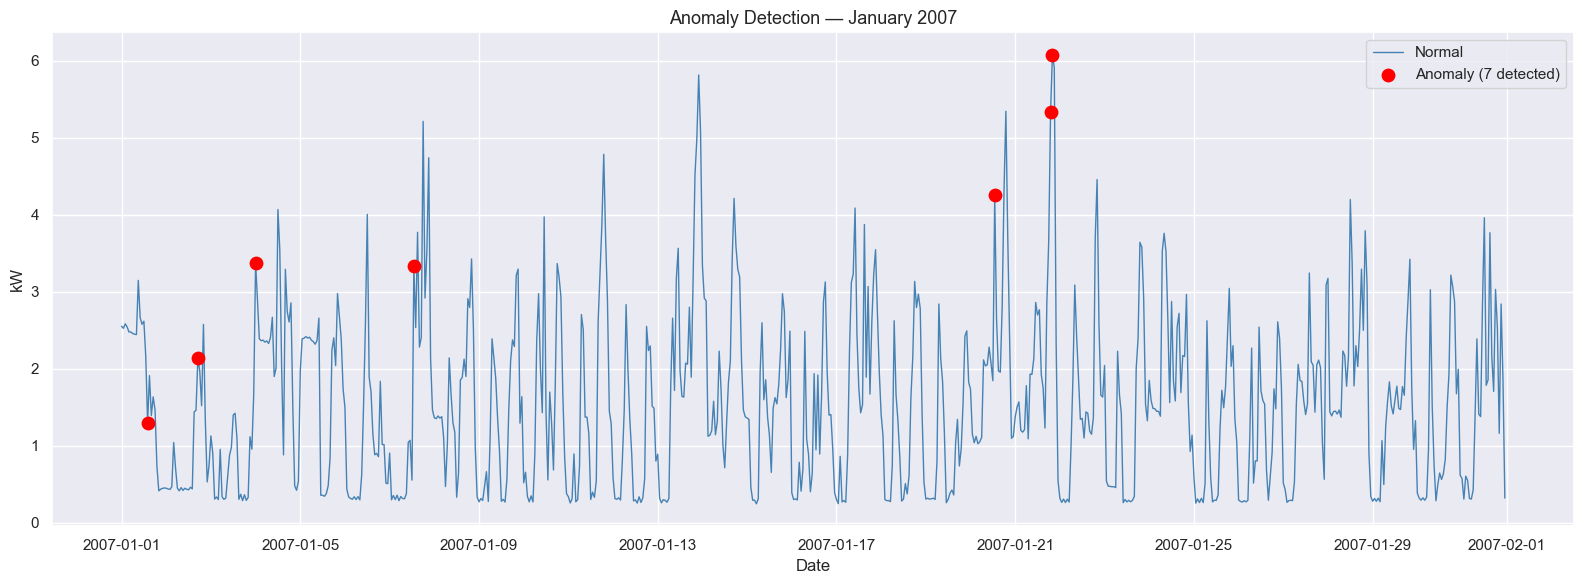


🚨 Sample Anomalies Detected:
                     Global_active_power   z_score
datetime                                          
2006-12-28 21:00:00             5.035333  3.172301
2007-01-01 14:00:00             1.294400 -3.629033
2007-01-02 17:00:00             2.136200  3.100175
2007-01-04 00:00:00             3.375067  3.687920
2007-01-07 13:00:00             3.331933  3.619638
2007-01-20 13:00:00             4.251033  3.192204
2007-01-21 19:00:00             5.330433  3.091419
2007-01-21 20:00:00             6.076567  3.013256
2007-02-06 21:00:00             2.779067  3.068563
2007-02-09 22:00:00             3.835767  3.015945


In [4]:
# 🚨 Anomaly Detection Engine
def detect_anomalies(df, window=24, threshold=3.0):
    """Detect anomalies using Z-score method on rolling window"""
    
    df_anomaly = df[['Global_active_power']].copy()
    
    # Calculate rolling mean and std
    df_anomaly['rolling_mean'] = df_anomaly['Global_active_power'].rolling(window=window).mean()
    df_anomaly['rolling_std']  = df_anomaly['Global_active_power'].rolling(window=window).std()
    
    # Calculate Z-score
    df_anomaly['z_score'] = (
        df_anomaly['Global_active_power'] - df_anomaly['rolling_mean']
    ) / df_anomaly['rolling_std']
    
    # Flag anomalies
    df_anomaly['is_anomaly'] = (np.abs(df_anomaly['z_score']) > threshold).astype(int)
    df_anomaly.dropna(inplace=True)
    
    return df_anomaly

df_anomaly = detect_anomalies(df)

# Stats
total_anomalies = df_anomaly['is_anomaly'].sum()
anomaly_pct     = df_anomaly['is_anomaly'].mean() * 100

print(f"✅ Anomaly Detection Complete!")
print(f"Total anomalies detected : {total_anomalies:,}")
print(f"Anomaly percentage       : {anomaly_pct:.2f}%")

# Plot anomalies — zoom into 1 month
df_plot = df_anomaly.loc['2007-01']

plt.figure(figsize=(16, 6))
plt.plot(df_plot.index, df_plot['Global_active_power'],
         color='steelblue', linewidth=1, label='Normal')

# Highlight anomalies
anomalies = df_plot[df_plot['is_anomaly'] == 1]
plt.scatter(anomalies.index, anomalies['Global_active_power'],
            color='red', s=80, zorder=5, label=f'Anomaly ({len(anomalies)} detected)')

plt.title('Anomaly Detection — January 2007', fontsize=13)
plt.xlabel('Date')
plt.ylabel('kW')
plt.legend()
plt.tight_layout()
plt.savefig('../data/anomaly_detection.png', dpi=150)
plt.show()

# Show anomaly details
print(f"\n🚨 Sample Anomalies Detected:")
print(df_anomaly[df_anomaly['is_anomaly']==1][['Global_active_power','z_score']].head(10))

✅ Cost Analysis Complete!

💰 Cost Summary (Full Dataset 2006-2010):
Total electricity cost    : ₹269,854.80
Optimized cost            : ₹254,467.21
Total savings             : ₹ 15,387.59
Savings percentage        :       5.70%


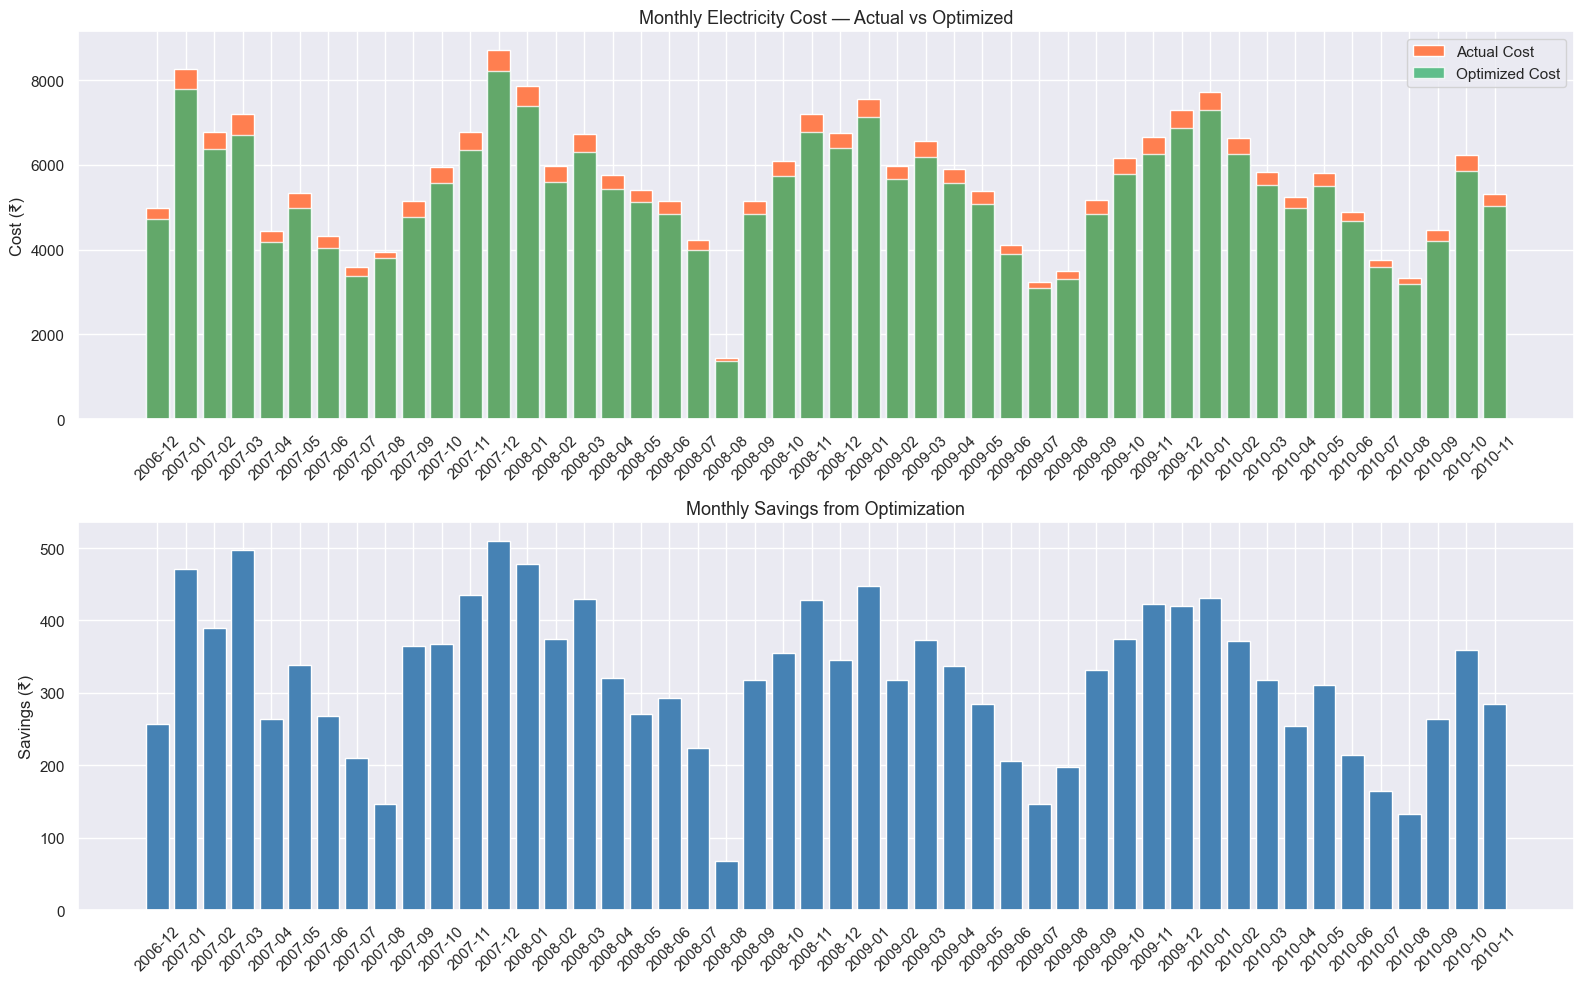

In [5]:
# 💰 Cost Calculator Engine
def calculate_costs(df, 
                    normal_rate=6.50,      # ₹ per kWh (Indian electricity rate)
                    peak_rate=9.75,        # ₹ per kWh (peak hours 50% higher)
                    peak_hours=[19,20,21], # detected peak hours
                    optimized_reduction=0.20):  # 20% reduction if optimized
    """
    Calculate electricity costs and potential savings
    normal_rate : cost per kWh during normal hours
    peak_rate   : cost per kWh during peak hours
    """
    
    df_cost = df[['Global_active_power']].copy()
    df_cost['hour'] = df_cost.index.hour
    
    # Assign rates based on peak/normal hours
    df_cost['rate'] = df_cost['hour'].apply(
        lambda h: peak_rate if h in peak_hours else normal_rate
    )
    
    # Calculate hourly cost (power in kW × 1 hour = kWh × rate)
    df_cost['hourly_cost']      = df_cost['Global_active_power'] * df_cost['rate']
    
    # Calculate optimized cost (shift loads away from peak)
    df_cost['optimized_power']  = df_cost.apply(
        lambda row: row['Global_active_power'] * (1 - optimized_reduction)
        if row['hour'] in peak_hours else row['Global_active_power'], axis=1
    )
    df_cost['optimized_cost']   = df_cost['optimized_power'] * df_cost['rate']
    
    # Calculate savings
    df_cost['savings']          = df_cost['hourly_cost'] - df_cost['optimized_cost']
    
    return df_cost

df_cost = calculate_costs(df)

# Summary statistics
total_cost      = df_cost['hourly_cost'].sum()
optimized_cost  = df_cost['optimized_cost'].sum()
total_savings   = df_cost['savings'].sum()
savings_pct     = (total_savings / total_cost) * 100

print(f"✅ Cost Analysis Complete!")
print(f"\n💰 Cost Summary (Full Dataset 2006-2010):")
print(f"{'='*45}")
print(f"Total electricity cost    : ₹{total_cost:>10,.2f}")
print(f"Optimized cost            : ₹{optimized_cost:>10,.2f}")
print(f"Total savings             : ₹{total_savings:>10,.2f}")
print(f"Savings percentage        : {savings_pct:>10.2f}%")
print(f"{'='*45}")

# Monthly breakdown
df_cost['month'] = df_cost.index.month
df_cost['year']  = df_cost.index.year

monthly = df_cost.groupby(['year','month']).agg(
    actual_cost   =('hourly_cost', 'sum'),
    optimized_cost=('optimized_cost', 'sum'),
    savings       =('savings', 'sum')
).reset_index()

# Plot monthly costs
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Monthly actual vs optimized cost
x = range(len(monthly))
axes[0].bar(x, monthly['actual_cost'], color='coral', 
            label='Actual Cost', edgecolor='white')
axes[0].bar(x, monthly['optimized_cost'], color='mediumseagreen',
            label='Optimized Cost', edgecolor='white', alpha=0.8)
axes[0].set_title('Monthly Electricity Cost — Actual vs Optimized', fontsize=13)
axes[0].set_ylabel('Cost (₹)')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{int(r['year'])}-{int(r['month']):02d}" 
                          for _, r in monthly.iterrows()], rotation=45)
axes[0].legend()

# Monthly savings
axes[1].bar(x, monthly['savings'], color='steelblue', edgecolor='white')
axes[1].set_title('Monthly Savings from Optimization', fontsize=13)
axes[1].set_ylabel('Savings (₹)')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{int(r['year'])}-{int(r['month']):02d}" 
                          for _, r in monthly.iterrows()], rotation=45)

plt.tight_layout()
plt.savefig('../data/cost_analysis.png', dpi=150)
plt.show()

✅ Appliance Schedule Generated!

🏠 Smart Appliance Scheduling Recommendations:
      Appliance  Power (kW)  Duration (hrs)  Peak Cost (₹)  Off-Peak Cost (₹)  Savings (₹)          Best Time    Avoid Time
Washing Machine         0.5             1.5           7.31               4.88         2.44 10:00 AM - 2:00 PM 19:00 - 22:00
     Dishwasher         1.2             1.0          11.70               7.80         3.90 10:00 AM - 2:00 PM 19:00 - 22:00
   Water Heater         2.0             1.0          19.50              13.00         6.50 10:00 AM - 2:00 PM 19:00 - 22:00
    EV Charging         3.3             4.0         128.70              85.80        42.90 11:00 PM - 5:00 AM 19:00 - 22:00
Air Conditioner         1.5             2.0          29.25              19.50         9.75 10:00 AM - 2:00 PM 19:00 - 22:00
          Dryer         0.7             1.0           6.82               4.55         2.27 10:00 AM - 2:00 PM 19:00 - 22:00
           Oven         2.1             1.0          

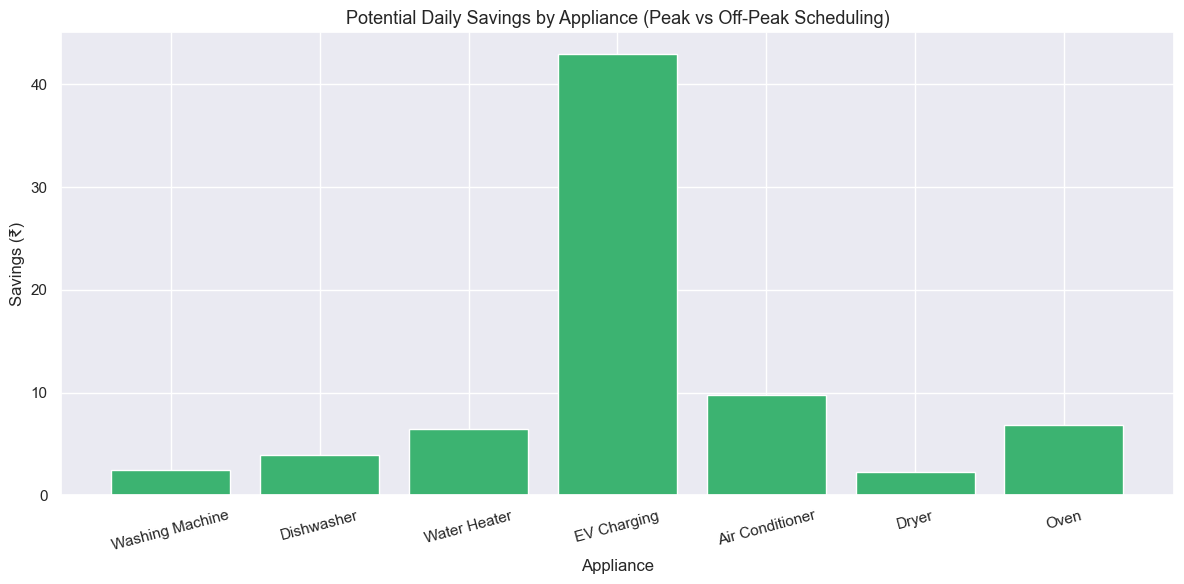

In [6]:
# 🏠 Appliance Scheduling Engine
def recommend_schedule(peak_hours=[19, 20, 21]):
    """
    Recommend optimal times to run high-power appliances
    to avoid peak hours and minimize cost
    """
    
    appliances = {
        'Washing Machine' : {'power_kw': 0.50, 'duration_hrs': 1.5},
        'Dishwasher'      : {'power_kw': 1.20, 'duration_hrs': 1.0},
        'Water Heater'    : {'power_kw': 2.00, 'duration_hrs': 1.0},
        'EV Charging'     : {'power_kw': 3.30, 'duration_hrs': 4.0},
        'Air Conditioner' : {'power_kw': 1.50, 'duration_hrs': 2.0},
        'Dryer'           : {'power_kw': 0.70, 'duration_hrs': 1.0},
        'Oven'            : {'power_kw': 2.10, 'duration_hrs': 1.0},
    }
    
    normal_rate = 6.50   # ₹ per kWh
    peak_rate   = 9.75   # ₹ per kWh
    
    # Find best off-peak hours (low consumption + normal rate)
    off_peak_hours = [h for h in range(24) if h not in peak_hours]
    best_hours     = [0, 1, 2, 3, 4, 5, 10, 11, 12, 13, 14]  # cheapest hours
    
    recommendations = []
    
    for appliance, specs in appliances.items():
        power    = specs['power_kw']
        duration = specs['duration_hrs']
        
        # Cost during peak hours
        peak_cost    = power * duration * peak_rate
        # Cost during off-peak hours
        offpeak_cost = power * duration * normal_rate
        # Savings
        savings      = peak_cost - offpeak_cost
        
        # Best time to run
        best_time = '10:00 AM - 2:00 PM' if duration <= 2 else '11:00 PM - 5:00 AM'
        avoid_time = f'{min(peak_hours)}:00 - {max(peak_hours)+1}:00'
        
        recommendations.append({
            'Appliance'       : appliance,
            'Power (kW)'      : power,
            'Duration (hrs)'  : duration,
            'Peak Cost (₹)'   : round(peak_cost, 2),
            'Off-Peak Cost (₹)': round(offpeak_cost, 2),
            'Savings (₹)'     : round(savings, 2),
            'Best Time'       : best_time,
            'Avoid Time'      : avoid_time
        })
    
    return pd.DataFrame(recommendations)

schedule_df = recommend_schedule()

print("✅ Appliance Schedule Generated!")
print(f"\n🏠 Smart Appliance Scheduling Recommendations:")
print(f"{'='*85}")
print(schedule_df.to_string(index=False))
print(f"{'='*85}")
print(f"\n💰 Total daily savings if all appliances scheduled optimally: "
      f"₹{schedule_df['Savings (₹)'].sum():.2f}")

# Plot savings per appliance
plt.figure(figsize=(12, 6))
colors = ['mediumseagreen' if s > 0 else 'coral' for s in schedule_df['Savings (₹)']]
plt.bar(schedule_df['Appliance'], schedule_df['Savings (₹)'], 
        color=colors, edgecolor='white')
plt.title('Potential Daily Savings by Appliance (Peak vs Off-Peak Scheduling)', fontsize=13)
plt.xlabel('Appliance')
plt.ylabel('Savings (₹)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../data/appliance_savings.png', dpi=150)
plt.show()

In [7]:
# 🧠 Smart Recommendations Engine
def generate_recommendations(df, df_anomaly, df_cost, peak_hours=[19, 20, 21]):
    """Generate personalized energy saving recommendations"""
    
    recommendations = []
    
    # 1. Peak hour usage analysis
    df['hour'] = df.index.hour
    peak_usage = df[df['hour'].isin(peak_hours)]['Global_active_power'].mean()
    normal_usage = df[~df['hour'].isin(peak_hours)]['Global_active_power'].mean()
    peak_ratio = peak_usage / normal_usage
    
    if peak_ratio > 1.3:
        recommendations.append({
            'Category'      : '⚡ Peak Hours',
            'Issue'         : f'Peak hour usage is {peak_ratio:.1f}x higher than normal',
            'Recommendation': 'Shift heavy appliances (washing machine, dishwasher) to 10AM-2PM',
            'Est. Savings'  : '₹200-400/month'
        })
    
    # 2. Nighttime usage analysis
    night_hours = [0, 1, 2, 3, 4, 5]
    night_usage = df[df['hour'].isin(night_hours)]['Global_active_power'].mean()
    
    if night_usage > 0.5:
        recommendations.append({
            'Category'      : '🌙 Nighttime Usage',
            'Issue'         : f'High nighttime consumption: {night_usage:.2f} kW avg',
            'Recommendation': 'Check for devices left on standby — unplug TVs, computers',
            'Est. Savings'  : '₹100-200/month'
        })
    
    # 3. Anomaly based recommendation
    anomaly_count = df_anomaly['is_anomaly'].sum()
    if anomaly_count > 100:
        recommendations.append({
            'Category'      : '🚨 Anomalies',
            'Issue'         : f'{anomaly_count} unusual consumption spikes detected',
            'Recommendation': 'Inspect appliances for faults — spikes may indicate faulty devices',
            'Est. Savings'  : '₹150-300/month'
        })
    
    # 4. Weekend vs weekday analysis
    df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
    weekend_usage  = df[df['is_weekend']==1]['Global_active_power'].mean()
    weekday_usage  = df[df['is_weekend']==0]['Global_active_power'].mean()
    
    if weekend_usage > weekday_usage * 1.1:
        recommendations.append({
            'Category'      : '📅 Weekend Usage',
            'Issue'         : f'Weekend usage {((weekend_usage/weekday_usage)-1)*100:.1f}% higher than weekdays',
            'Recommendation': 'Schedule high-power tasks during weekday off-peak hours instead',
            'Est. Savings'  : '₹100-250/month'
        })
    
    # 5. Seasonal recommendation
    df['month'] = df.index.month
    monthly_avg = df.groupby('month')['Global_active_power'].mean()
    peak_month  = monthly_avg.idxmax()
    month_names = {1:'January', 2:'February', 3:'March', 4:'April',
                   5:'May', 6:'June', 7:'July', 8:'August',
                   9:'September', 10:'October', 11:'November', 12:'December'}
    
    recommendations.append({
        'Category'      : '🌦️ Seasonal',
        'Issue'         : f'Highest consumption in {month_names[peak_month]}',
        'Recommendation': 'Pre-cool/pre-heat home before peak hours using smart thermostat',
        'Est. Savings'  : '₹200-500/month'
    })
    
    # 6. Overall efficiency score
    avg_consumption = df['Global_active_power'].mean()
    if avg_consumption > 1.5:
        recommendations.append({
            'Category'      : '🏠 Overall Efficiency',
            'Issue'         : f'Average consumption {avg_consumption:.2f} kW is above optimal',
            'Recommendation': 'Consider upgrading to energy-efficient appliances (5-star rating)',
            'Est. Savings'  : '₹500-1000/month'
        })
    
    return pd.DataFrame(recommendations)

rec_df = generate_recommendations(df, df_anomaly, df_cost)

print("✅ Recommendations Generated!")
print(f"\n🧠 Smart Energy Saving Recommendations:")
print(f"{'='*90}")
for _, row in rec_df.iterrows():
    print(f"\n{row['Category']}")
    print(f"  ⚠️  Issue          : {row['Issue']}")
    print(f"  ✅ Recommendation  : {row['Recommendation']}")
    print(f"  💰 Est. Savings    : {row['Est. Savings']}")
print(f"\n{'='*90}")

# Save recommendations
rec_df.to_csv('../data/recommendations.csv', index=False)
print(f"\n✅ Recommendations saved → data/recommendations.csv")

✅ Recommendations Generated!

🧠 Smart Energy Saving Recommendations:

⚡ Peak Hours
  ⚠️  Issue          : Peak hour usage is 1.9x higher than normal
  ✅ Recommendation  : Shift heavy appliances (washing machine, dishwasher) to 10AM-2PM
  💰 Est. Savings    : ₹200-400/month

🌙 Nighttime Usage
  ⚠️  Issue          : High nighttime consumption: 0.51 kW avg
  ✅ Recommendation  : Check for devices left on standby — unplug TVs, computers
  💰 Est. Savings    : ₹100-200/month

🚨 Anomalies
  ⚠️  Issue          : 293 unusual consumption spikes detected
  ✅ Recommendation  : Inspect appliances for faults — spikes may indicate faulty devices
  💰 Est. Savings    : ₹150-300/month

📅 Weekend Usage
  ⚠️  Issue          : Weekend usage 17.7% higher than weekdays
  ✅ Recommendation  : Schedule high-power tasks during weekday off-peak hours instead
  💰 Est. Savings    : ₹100-250/month

🌦️ Seasonal
  ⚠️  Issue          : Highest consumption in December
  ✅ Recommendation  : Pre-cool/pre-heat home before pe

In [8]:
import os

# Save all optimization results
os.makedirs('../data', exist_ok=True)

# Save peak hour analysis
df_analysis.to_csv('../data/peak_hour_analysis.csv')

# Save anomaly detection results
df_anomaly.to_csv('../data/anomaly_detection.csv')

# Save cost analysis
df_cost.to_csv('../data/cost_analysis.csv')

# Save schedule
schedule_df.to_csv('../data/appliance_schedule.csv', index=False)

# Final optimization summary
summary = {
    'Total Hours Analyzed'      : len(df),
    'Peak Hours Detected'       : str([19, 20, 21]),
    'Total Anomalies'           : int(df_anomaly['is_anomaly'].sum()),
    'Anomaly Percentage'        : f"{df_anomaly['is_anomaly'].mean()*100:.2f}%",
    'Total Electricity Cost'    : f"₹{df_cost['hourly_cost'].sum():,.2f}",
    'Optimized Cost'            : f"₹{df_cost['optimized_cost'].sum():,.2f}",
    'Total Savings'             : f"₹{df_cost['savings'].sum():,.2f}",
    'Savings Percentage'        : f"{(df_cost['savings'].sum()/df_cost['hourly_cost'].sum())*100:.2f}%",
    'Recommendations Generated' : len(rec_df),
    'Best Model'                : 'XGBoost (R²=0.5937, MAPE=42.71%)',
}

summary_df = pd.Series(summary).to_frame('Value')
summary_df.index.name = 'Metric'
summary_df.to_csv('../data/optimization_summary.csv')

print("✅ All optimization results saved!")
print(f"\n📁 Files saved to data/ folder:")
for f in sorted(os.listdir('../data')):
    size = os.path.getsize(f'../data/{f}')
    print(f"   → {f:<40} ({size:,} bytes)")

print(f"\n🎯 Optimization Summary:")
print(f"{'='*50}")
for metric, value in summary.items():
    print(f"{metric:<35} : {value}")
print(f"{'='*50}")

✅ All optimization results saved!

📁 Files saved to data/ folder:
   → anomaly_detection.csv                    (3,273,688 bytes)
   → anomaly_detection.png                    (245,890 bytes)
   → appliance_savings.png                    (56,013 bytes)
   → appliance_schedule.csv                   (587 bytes)
   → baseline_predictions.csv                 (449,473 bytes)
   → cleaned_hourly.csv                       (3,933,572 bytes)
   → cost_analysis.csv                        (3,557,527 bytes)
   → cost_analysis.png                        (110,005 bytes)
   → feature_importance.png                   (71,656 bytes)
   → household_power_consumption.txt          (132,960,755 bytes)
   → lstm_predictions.png                     (563,165 bytes)
   → lstm_training_history.png                (100,878 bytes)
   → optimization_summary.csv                 (330 bytes)
   → peak_hour_analysis.csv                   (1,752,021 bytes)
   → peak_hours.png                           (53,309 bytes)
   